# 02 · Part A — The A/B Test

The data is a genuine randomized experiment, so a treated-vs-control comparison **is** the causal effect. This notebook runs that comparison rigorously: SRM check, power/sample size, primary (conversion) and secondary (spend) tests with confidence intervals, effect sizes, guardrails, multiple-testing correction, and a translation into dollars.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "src").exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import data_prep as dp
from src import ab_test as ab

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

df = dp.add_treatment_flag(dp.load_raw())
treat = df[df.treatment == 1]
control = df[df.treatment == 0]
n_t, n_c = len(treat), len(control)
print(f"treated (any email): {n_t:,}    control (no email): {n_c:,}")

treated (any email): 42,694    control (no email): 21,306


## 1. Sample Ratio Mismatch (SRM)

Chi-square goodness-of-fit on the split. The intended treated share is 2/3; a significant deviation (p < 0.001) means the experiment is broken and no downstream number can be trusted.

In [2]:
srm = ab.srm_check(n_t, n_c, expected_treat_share=2/3)
for k, val in srm.items():
    print(f"  {k}: {val}")
print("\n=> SRM detected:", srm["srm_detected"], "(False = split is fine, proceed)")

  observed: [42694, 21306]
  expected: [42666.7, 21333.3]
  chi2: 0.052531250000009314
  p_value: 0.8187158292900667
  srm_detected: False

=> SRM detected: False (False = split is fine, proceed)


## 2. Power & sample size

At 80% power and α = 0.05, the sample size needed to detect the observed effect vs a modest +20% relative lift on the same baseline.

In [3]:
p_c = control.conversion.mean()
p_t = treat.conversion.mean()

n_obs = ab.required_sample_size(p_c, p_t)          # to detect the observed effect
n_mde = ab.required_sample_size(p_c, p_c * 1.20)   # to detect a modest +20% lift
power_here = ab.power_at_sample_size(p_c, p_t, n_c)

print(f"control conversion p_c = {p_c:.4f}")
print(f"treated conversion p_t = {p_t:.4f}   (relative lift {p_t/p_c - 1:+.0%})")
print(f"required n/group to detect the OBSERVED effect : {n_obs:,.0f}")
print(f"required n/group to detect a modest +20% lift  : {n_mde:,.0f}")
print(f"our control n = {n_c:,}  ->  power for observed effect = {power_here:.3f}")

control conversion p_c = 0.0057
treated conversion p_t = 0.0107   (relative lift +87%)
required n/group to detect the OBSERVED effect : 5,082
required n/group to detect a modest +20% lift  : 74,760
our control n = 21,306  ->  power for observed effect = 1.000


Well-powered for the large effect observed, but detecting a +20% lift on a 0.9% base would need far more customers than we have — on rare outcomes even 64k users can be underpowered.

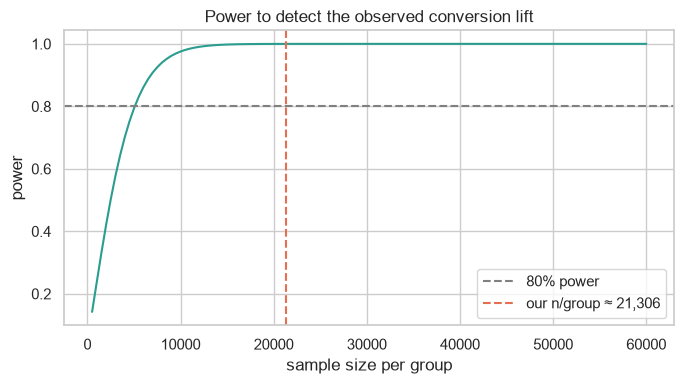

In [4]:
ns = np.linspace(500, 60000, 120)
powers = [ab.power_at_sample_size(p_c, p_t, n) for n in ns]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, powers, color="#2a9d8f")
ax.axhline(0.8, color="grey", ls="--", label="80% power")
ax.axvline(n_c, color="#e76f51", ls="--", label=f"our n/group ≈ {n_c:,}")
ax.set_xlabel("sample size per group"); ax.set_ylabel("power")
ax.set_title("Power to detect the observed conversion lift"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "02_power_curve.png", dpi=120, bbox_inches="tight"); plt.show()

## 3. Primary test — conversion (two-proportion z-test)

Lift in percentage points, relative lift, p-value, and the 95% confidence interval of the lift.

In [5]:
r = ab.two_proportion_ztest(int(treat.conversion.sum()), n_t,
                            int(control.conversion.sum()), n_c)
print("CONVERSION")
print(f"  control = {r.p_control:.4%}    treated = {r.p_treat:.4%}")
print(f"  absolute lift = {r.abs_lift*100:+.3f} pp    relative lift = {r.rel_lift:+.1%}")
print(f"  z = {r.z_stat:.3f}    p = {r.p_value:.2e}")
print(f"  95% CI of lift = [{r.ci_low*100:+.3f}, {r.ci_high*100:+.3f}] pp")
print(f"  Cohen's h = {r.cohens_h:.3f}")

CONVERSION
  control = 0.5726%    treated = 1.0681%
  absolute lift = +0.495 pp    relative lift = +86.5%
  z = 6.244    p = 4.27e-10
  95% CI of lift = [+0.355, +0.636] pp
  Cohen's h = 0.056


## 4. Secondary test — spend (Welch's t-test)

Spend is continuous, zero-inflated, and skewed with unequal group variances, so we use Welch's t-test.

In [6]:
s = ab.welch_ttest(treat.spend.values, control.spend.values)
print("SPEND")
print(f"  control mean = ${s.mean_control:.3f}    treated mean = ${s.mean_treat:.3f}")
print(f"  difference = ${s.diff:+.3f}    t = {s.t_stat:.3f}    p = {s.p_value:.2e}")
print(f"  95% CI of difference = [${s.ci_low:+.3f}, ${s.ci_high:+.3f}]")
print(f"  Cohen's d = {s.cohens_d:.3f}  (small — spend is ~99% zeros)")

SPEND
  control mean = $0.653    treated mean = $1.250
  difference = $+0.597    t = 5.302    p = 1.15e-07
  95% CI of difference = [$+0.376, $+0.817]
  Cohen's d = 0.042  (small — spend is ~99% zeros)


## 5. Effect sizes & the visit outcome

Test `visit` (a guardrail and part of the multiple-testing correction); pair every p-value with an effect size.

In [7]:
v = ab.two_proportion_ztest(int(treat.visit.sum()), n_t,
                            int(control.visit.sum()), n_c)
summary = pd.DataFrame([
    {"outcome": "visit",      "control": f"{v.p_control:.4%}", "treated": f"{v.p_treat:.4%}",
     "lift": f"{v.abs_lift*100:+.3f} pp", "p_value": v.p_value, "effect": f"h={v.cohens_h:.3f}"},
    {"outcome": "conversion", "control": f"{r.p_control:.4%}", "treated": f"{r.p_treat:.4%}",
     "lift": f"{r.abs_lift*100:+.3f} pp", "p_value": r.p_value, "effect": f"h={r.cohens_h:.3f}"},
    {"outcome": "spend",      "control": f"${s.mean_control:.3f}", "treated": f"${s.mean_treat:.3f}",
     "lift": f"${s.diff:+.3f}", "p_value": s.p_value, "effect": f"d={s.cohens_d:.3f}"},
])
summary

,outcome,control,treated,lift,p_value,effect
0,visit,10.6167%,16.7049%,+6.088 pp,1.749787e-93,h=0.178
1,conversion,0.5726%,1.0681%,+0.495 pp,4.271614e-10,h=0.056
2,spend,$0.653,$1.250,$+0.597,1.148372e-07,d=0.042


## 6. Guardrail metrics

Confirm neither visit nor spend regressed — a win on conversion shouldn't quietly hurt another metric.

In [8]:
print("Guardrails (must not regress):")
print(f"  visit lift = {v.abs_lift*100:+.3f} pp   -> {'OK' if v.abs_lift > 0 else 'REGRESSED'}")
print(f"  spend diff = ${s.diff:+.3f}       -> {'OK' if s.diff > 0 else 'REGRESSED'}")
print("\nNote: a real campaign would also guard unsubscribe / complaint / margin. Those columns are")
print("not in this dataset, so we flag it as a monitoring gap rather than claim they're fine.")

Guardrails (must not regress):
  visit lift = +6.088 pp   -> OK
  spend diff = $+0.597       -> OK

Note: a real campaign would also guard unsubscribe / complaint / margin. Those columns are
not in this dataset, so we flag it as a monitoring gap rather than claim they're fine.


## 7. Multiple-testing correction

Adjust the three outcome p-values with Bonferroni and Benjamini-Hochberg.

In [9]:
pvals = [v.p_value, r.p_value, s.p_value]
bonf = ab.correct_pvalues(pvals, "bonferroni")
bh = ab.correct_pvalues(pvals, "fdr_bh")
pd.DataFrame({
    "outcome": ["visit", "conversion", "spend"],
    "raw_p": pvals,
    "bonferroni_p": bonf["p_adjusted"],
    "bh_p": bh["p_adjusted"],
    "still_significant": bh["reject_h0"],
})

,outcome,raw_p,bonferroni_p,bh_p,still_significant
0,visit,1.749787e-93,5.249361e-93,5.249361e-93,True
1,conversion,4.271614e-10,1.281484e-09,6.407421e-10,True
2,spend,1.148372e-07,3.445116e-07,1.148372e-07,True


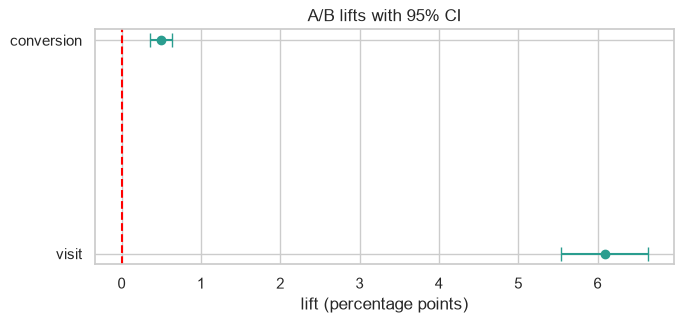

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.4))
rows = [("visit", v), ("conversion", r)]
for i, (name, res) in enumerate(rows):
    ax.errorbar(res.abs_lift*100, i,
                xerr=[[(res.abs_lift - res.ci_low)*100], [(res.ci_high - res.abs_lift)*100]],
                fmt="o", color="#2a9d8f", capsize=5)
ax.axvline(0, color="red", ls="--")
ax.set_yticks(range(len(rows))); ax.set_yticklabels([n for n, _ in rows])
ax.set_xlabel("lift (percentage points)"); ax.set_title("A/B lifts with 95% CI")
fig.tight_layout(); fig.savefig(FIG_DIR / "02_ab_lifts_ci.png", dpi=120, bbox_inches="tight"); plt.show()

## 8. Translate to dollars

Turn the causal incremental spend per treated customer into profit at 30% margin and $0.10 cost per send.

In [11]:
spend_ate = s.diff  # causal incremental spend per treated customer
impact = ab.business_impact(spend_ate, n_targeted=n_t, margin=0.30, cost_per_send=0.10)

print("HEADLINE")
print(f"  Each emailed customer spends ${impact['incremental_spend_per_customer']:.3f} more on average.")
print(f"  At 30% margin that's ${impact['incremental_margin_per_customer']:.3f} profit, minus $0.10 cost")
print(f"  = ${impact['net_profit_per_customer']:.3f} net per customer   (ROI {impact['roi']:+.0%}).")
print(f"  Across the {impact['n_targeted']:,} treated customers "
      f"≈ ${impact['total_net_profit']:,.0f} incremental profit.")

HEADLINE
  Each emailed customer spends $0.597 more on average.
  At 30% margin that's $0.179 profit, minus $0.10 cost
  = $0.079 net per customer   (ROI +79%).
  Across the 42,694 treated customers ≈ $3,374 incremental profit.


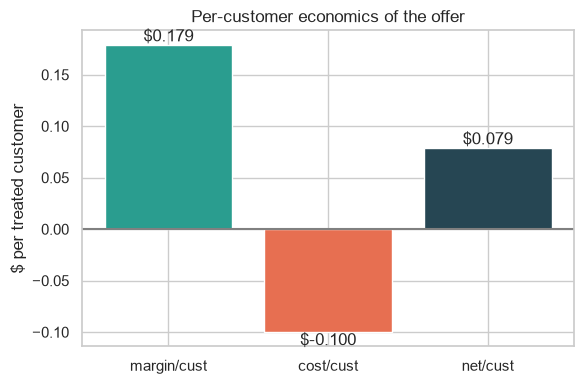

In [12]:
labels = ["margin/cust", "cost/cust", "net/cust"]
vals = [impact["incremental_margin_per_customer"], -impact["cost_per_customer"],
        impact["net_profit_per_customer"]]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, vals, color=["#2a9d8f", "#e76f51", "#264653"])
ax.axhline(0, color="grey")
ax.set_ylabel("$ per treated customer"); ax.set_title("Per-customer economics of the offer")
for i, val in enumerate(vals):
    ax.text(i, val, f"${val:.3f}", ha="center", va="bottom" if val >= 0 else "top")
fig.tight_layout(); fig.savefig(FIG_DIR / "02_economics.png", dpi=120, bbox_inches="tight"); plt.show()

## Part A takeaways from above results

- The split is clean (no SRM) and randomized, so these lifts are the true causal effects.
- Email strongly lifts visits and roughly doubles conversion, both highly significant and robust to multiple-testing correction.
- Conversion's absolute lift is small (rare event); well-powered for the observed effect but underpowered for a smaller lift.
- Guardrails hold (unsubscribe/complaint metrics aren't in this dataset).
- At 30% margin and $0.10/send the offer nets a positive profit per customer.